# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 2</span>
### <span style= "color: black" > Es02.1

Lo scopo di questo esercizio è calcolare il seguente integrale $$I = \int_0^1 \frac{\pi}{2}\cos\left(\frac{\pi x}{2}\right) dx = 1$$
utilizzando due metodi:
1. campionando una distribuzione di probabilità uniforme in $[0,1]$;
2. usando l'importance sampling, cioè campionando una distribuzione di probabilità non uniforme in $[0,1]$.

Per stimare il valore di $I$ è stato utilizzato il metodo del data blocking con $N = 100$ blocchi e $M = 10^4$ lanci totali.

L’obiettivo è rappresentare graficamente il valore di $I$, più precisamente $I-1$, con la relativa incertezza, ottenuto sia con campionamento uniforme sia con importance sampling, in funzione del numero di blocchi $N$.

Inizialmente è stata considerata $p(x) = 1$ come distribuzione di probabilità uniforme. Tuttavia, $p(x)$ non è la scelta più adatta per il calcolo di questo integrale.

Per calcolare $I$ usando l'importance sampling, viene estratto $x$ da una distribuzione di probabilità $g(x)$ che approssima meglio l'integranda nell'intervallo considerato, cioè $[0,1]$.
In particolare, la distribuzione di probabilità utilizzata è: $$ g(x) = 2(1-x) $$ Per estrarre $x$ da $g(x)$ è stato usato il metodo dell’inversa della funzione cumulativa di $g(x)$.
Ci si aspetta che questa scelta riduca significativamente la varianza della stima di $I$.

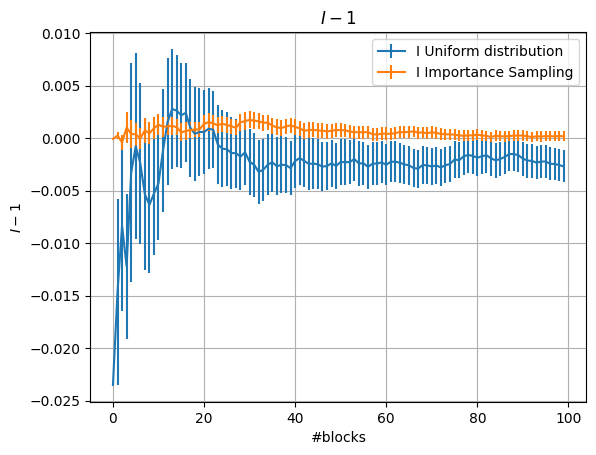

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np 
import math

# Load data from file
x, f, error = np.loadtxt("Es02.1/output1.txt", usecols=(0, 1, 2), delimiter=' ', unpack=True)
x2, f2, error2 = np.loadtxt("Es02.1/output2.txt", usecols=(0, 1, 2), delimiter=' ', unpack=True)

# Plot data with error bars
plt.errorbar(x, f, yerr=error, label='I Uniform distribution')
plt.errorbar(x2, f2, yerr=error2, label= 'I Importance Sampling')

plt.xlabel('#blocks')
plt.ylabel(r"$I-1$")
plt.title(r"$I-1$")
plt.grid(True)
plt.legend()
plt.show()
    


Come previsto, si osserva che il valore di $I-1$ ottenuto con l'importance sampling tende a $0$ più rapidamente e in modo più accurato.
In particolare, le barre d’errore risultano significativamente ridotte rispetto al caso con in cui si è utitlizzata la distribuzione uniforme.

### <span style= "color: black" > Es02.2

Questo esercizio riguarda i *Random Walk* tridimensionali. Verranno simulati:

1. un random walk su un reticolo cubico con passo reticolare $a = 1$. Partendo dall’origine, a ogni tempo discreto il random walker si muove avanti o indietro lungo la direzione $x$, $y$ o $z$, raggiungendo uno dei siti vicini.

2. un random walk nel continuo. Partendo dall’origine, a ogni tempo discreto il random walker compie un passo di lunghezza $a =1$ lungo una direzione casuale, ottenuta campionando uniformemente l’angolo solido: $\theta \in [0,\pi]$ e $\phi \in [0,2\pi]$.

Si vuole rappresentare graficamente $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ per entrambi i random walk, con le rispettive incertezze statistiche, in funzione dello step $i \in [0,10^2]$.

Per stimare $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ è stato usato come sempre il metodo del data blocking, con $N = 100$ blocchi e un numero totale di _throws_ — in questo caso, numero totale di random walk — pari a $M = 10^4$.

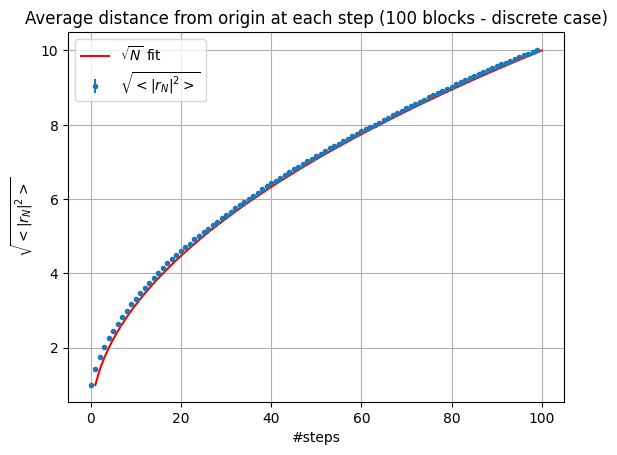

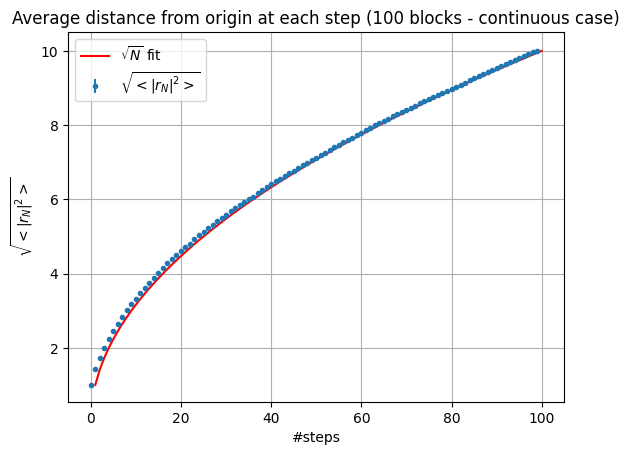

In [ ]:
def plot(filename, title, data):
    # Load data from file
    x, f, error = np.loadtxt(filename, usecols=(0, 1, 2), delimiter=' ', unpack=True)
    # Plot data with error bars
    plt.errorbar(x, f, yerr=error, fmt = 'o', markersize = 3, label = data )
    plt.xlabel('#steps')
    plt.ylabel(data)
    plt.title(title)
    plt.grid(True)
    plt.plot(N, sqrt_N, label=r'$\sqrt{N}$ fit', color='red')
    plt.legend()
    plt.show()

#sqrt(N) fit teorico
N = np.arange(1, 101)
sqrt_N = np.sqrt(N)
    
plot("Es02.2/output_discrete.txt", "Average distance from origin at each step (100 blocks - discrete case)",'$\sqrt{<|r_N|^2>}$' )

plot("Es02.2/output_continuous.txt", "Average distance from origin at each step (100 blocks - continuous case)",'$\sqrt{<|r_N|^2>}$' )

In entrambi i casi si osserva che i dati della simulazione seguono perfettamente il fit $f(N)=k\sqrt{N}$, quindi questo significa che si osserva un comportamento diffusivo. In entrambi i casi $k$ risulta essere $\sim$ 1.